In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder



In [6]:
# Load the dataset
data = pd.read_csv('../../data/raw/Customers.csv')

# Clean the data - remove missing values and obvious nonsense ages

df_clean = data.dropna(subset=["Annual Income ($)", "Spending Score (1-100)"])
df_clean = df_clean[df_clean["Age"] > 0]


In [7]:
df_clean.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [8]:
# find values of age less than 18
df_clean[df_clean["Age"] < 18]

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
202,203,Female,16,60000,0,Engineer,6,8
210,211,Female,1,57000,93,Engineer,1,2
229,230,Male,15,94000,30,Healthcare,7,2
230,231,Female,6,93000,53,Lawyer,8,2
234,235,Female,4,84000,54,Artist,9,1
...,...,...,...,...,...,...,...,...
1955,1956,Female,11,181026,39,Marketing,6,2
1974,1975,Female,14,153145,59,Healthcare,8,6
1980,1981,Female,10,86925,76,Artist,7,2
1984,1985,Female,2,153622,51,Lawyer,6,6


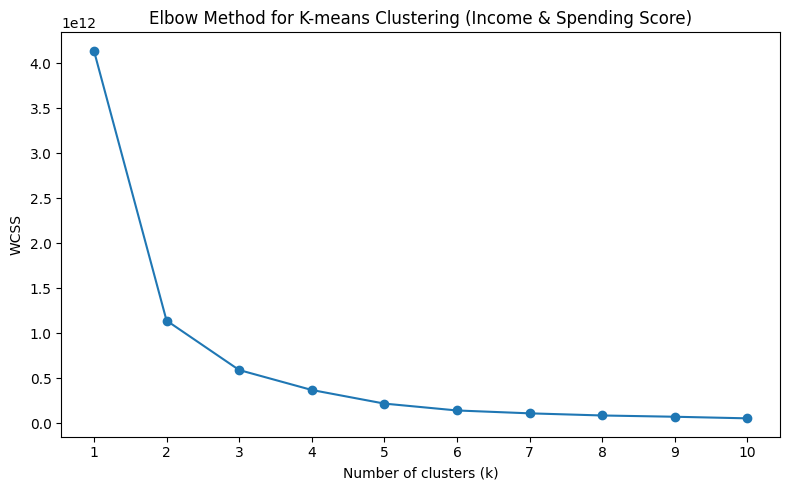

In [9]:
# K-means clustering on income and spending score
X = df_clean[["Annual Income ($)", "Spending Score (1-100)" ]]
wcss_income_score = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss_income_score.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss_income_score, marker='o')
plt.title('Elbow Method for K-means Clustering (Income & Spending Score)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.tight_layout()
plt.show()
              

In [10]:
# Choose k=5 based on the elbow plot
k_income_score = 5
kmeans_income_score = KMeans(n_clusters=k_income_score, random_state=42, n_init=10)

# Fit the model and predict cluster labels
df_clean['Cluster_Income_Score'] = kmeans_income_score.fit_predict(X)

# Cluster means for interpretation
income_score_means = df_clean.groupby('Cluster_Income_Score')[
    ["Annual Income ($)", 
     "Spending Score (1-100)", 
     "Age", "Work Experience", 
     "Family Size"]
     ].mean()

print(income_score_means)

                                                               

                      Annual Income ($)  Spending Score (1-100)        Age  \
Cluster_Income_Score                                                         
0                         136362.149789               52.472574  51.432489   
1                          65251.447257               49.677215  48.044304   
2                         172705.400000               50.676190  48.638095   
3                          98156.897751               51.231084  51.071575   
4                          21840.336134               48.941176  45.092437   

                      Work Experience  Family Size  
Cluster_Income_Score                                
0                            4.301688     4.046414  
1                            3.805907     3.713080  
2                            4.440476     3.828571  
3                            4.161554     3.705521  
4                            3.084034     2.865546  


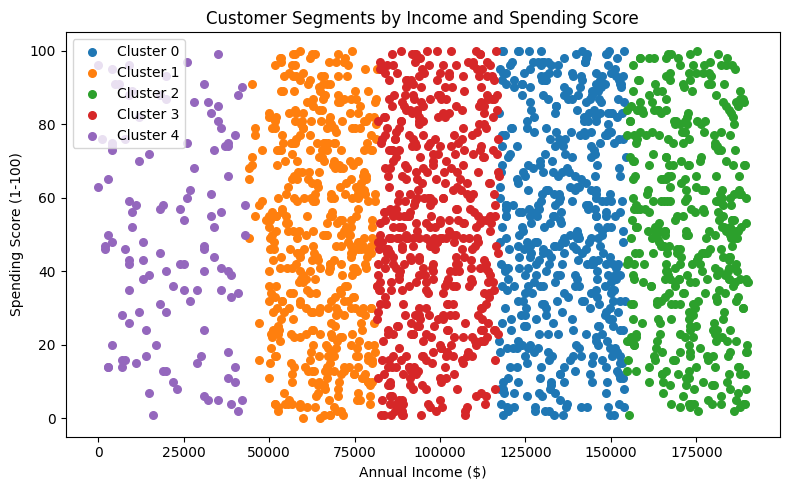

In [13]:
#scatter plot of clusters
plt.figure(figsize=(8, 5))
for cluster in range(k_income_score):
    cluster_data = X[df_clean['Cluster_Income_Score'] == cluster]
    plt.scatter(cluster_data["Annual Income ($)"], cluster_data["Spending Score (1-100)"], label=f'Cluster {cluster}', s=30)

plt.title('Customer Segments by Income and Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

This shows us that there are people with incomes at all ranges but their spending scores don't necessarily correlate - i.e. there are data points in the low income range with high spending scores, but there are also data points in the high income ranges with low spending scores. So we have to look at other features as well.

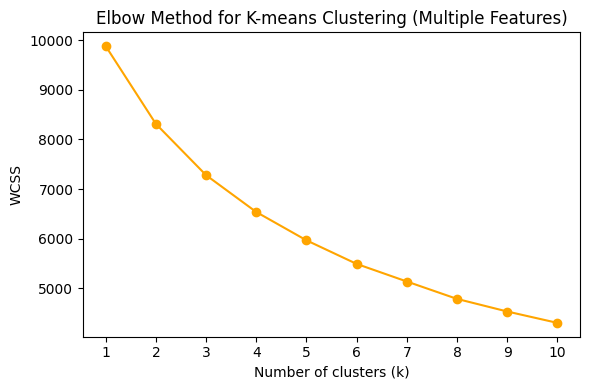

In [15]:
# k-means on multiple numerical features

features = ["Annual Income ($)", "Spending Score (1-100)", "Age", "Work Experience", "Family Size"]
X_multi = df_clean[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

wcss_multi = []
for k in K_range:
    kmeans_multi = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans_multi.fit(X_scaled)
    wcss_multi.append(kmeans_multi.inertia_) 

# Elbow plot for multi-feature clustering
plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss_multi, marker='o', color='orange')
plt.title('Elbow Method for K-means Clustering (Multiple Features)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.xticks(K_range) # Ensure x-ticks match the range of k
plt.tight_layout()
plt.show()

In [18]:
k_multi = 6
kmeans_multi = KMeans(n_clusters=k_multi, random_state=42, n_init=10)
df_clean['Cluster_Multi'] = kmeans_multi.fit_predict(X_scaled)

# Cluster means for multi-feature clustering
multi_means = df_clean.groupby('Cluster_Multi')[features].mean()
print("\nCluster means for multi-feature clustering:")
print(multi_means)


Cluster means for multi-feature clustering:
               Annual Income ($)  Spending Score (1-100)        Age  \
Cluster_Multi                                                         
0                  121862.538462               44.638177  73.672365   
1                  114224.121302               47.573964  68.633136   
2                   66654.500000               25.081325  40.867470   
3                   74815.855908               79.636888  41.172911   
4                  137623.729373               57.161716  23.478548   
5                  155826.052459               50.983607  45.554098   

               Work Experience  Family Size  
Cluster_Multi                                
0                     2.085470     5.803419  
1                     9.284024     3.071006  
2                     2.876506     2.882530  
3                     2.141210     3.020173  
4                     6.399340     5.620462  
5                     1.977049     2.150820  


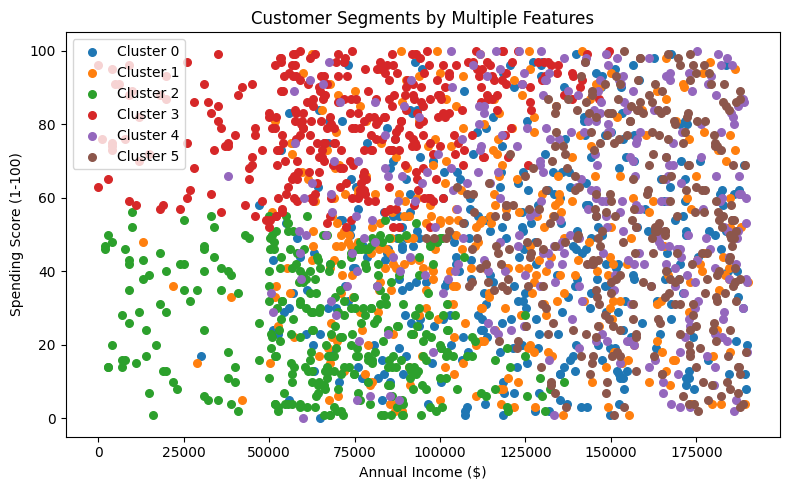

In [19]:
# scatter plot of multi-feature clusters
plt.figure(figsize=(8, 5))
for cluster in range(k_multi):
    cluster_data = X[df_clean['Cluster_Multi'] == cluster]
    plt.scatter(cluster_data["Annual Income ($)"], cluster_data["Spending Score (1-100)"], label=f'Cluster {cluster}', s=30)

plt.title('Customer Segments by Multiple Features')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

use both categorical and numerical features and create clusters using multiple features together

In [25]:
numeric_features = ["Annual Income ($)", "Spending Score (1-100)", "Age", "Work Experience", "Family Size"]
categorical_features = ["Gender", "Profession"] 

#preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) 
    ]
)

X_preprocessed = preprocessor.fit_transform(df_clean)

wcss_preprocessed = []
for k in range(2,11):
    kmeans_preprocessed = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_preprocessed.fit(X_preprocessed)
    wcss_preprocessed.append(kmeans_preprocessed.inertia_)

# fit k-means on preprocessed data
k_preprocessed = 5
kmeans_preprocessed = KMeans(n_clusters=k_preprocessed, random_state=42, n_init=10)
kmeans_preprocessed.fit(X_preprocessed)
df_clean['Cluster_Preprocessed'] = kmeans_preprocessed.fit_predict(X_preprocessed)

# cluster summaries
cluster_summary = df_clean.groupby('Cluster_Preprocessed')[features + categorical_features].mean(numeric_only=True).join(
    df_clean.groupby('Cluster_Preprocessed')[categorical_features].agg(lambda x: x.mode()[0])
)

profession_distribution = df_clean.groupby('Cluster_Preprocessed')['Profession'].value_counts(normalize=True)
gender_distribution = df_clean.groupby('Cluster_Preprocessed')['Gender'].value_counts(normalize=True)
print("\nCluster summary for preprocessed data:")
print(cluster_summary)
print("\nProfession distribution by cluster:")
print(profession_distribution)
print("\nGender distribution by cluster:")
print(gender_distribution)



Cluster summary for preprocessed data:
                      Annual Income ($)  Spending Score (1-100)        Age  \
Cluster_Preprocessed                                                         
0                         124433.476712               40.030137  26.863014   
1                          96792.652812               79.151589  31.188264   
2                         122735.201005               63.065327  77.361809   
3                         118506.700258               41.428941  50.767442   
4                          93481.340528               29.884892  59.764988   

                      Work Experience  Family Size  Gender Profession  
Cluster_Preprocessed                                                   
0                            3.591781     5.810959  Female     Artist  
1                            2.865526     2.640587  Female     Artist  
2                            3.376884     5.391960  Female     Artist  
3                            9.405685     2.842377  F